# Project 1 · 02：从 MIL / MLIR 到自定义 NPU 的玩具编译器

> **一句话心智模型：** IR 颗粒度不是越细越好；每一层 IR 都要保留“当前优化需要的语义”，同时显式化“下一层必须管理的硬件细节”。编译就是反复执行：**暴露一种结构 → 在结构仍清晰时优化 → 再 lower 一层**。

本篇不改 `01_resnet50_backend_comparison.ipynb`，而是用一颗假想 NPU 搭建独立、可执行的 compiler lab。你会同时看到：

- Core ML MIL 的真实 Python 对象类型与 ML Program protobuf 类型；
- ONNX protobuf 与 MIL SSA 对象图在存储和改图方式上的区别；
- 一个仿 MLIR 的 `Operation → Region → Block → Operation` 递归 IR；
- fusion、tiling、dialect lowering、缺 kernel 时的 fallback / 自定义 kernel / epilogue fusion；
- cost model、指令计数、DRAM 流量与 correctness gate。

## Goal：一颗假想的玩具 NPU，和一条三层 IR 流水线

我们自造一颗 NPU（规格全靠假设，量级参考入门级端侧 NPU）：

| 部件 | 假设规格 | 对应真实世界 |
|---|---|---|
| MMA 阵列 | 256 MAC/cycle，一条 `mma` 指令吃 `(m=16, k=32, n=16)` 的 tile | 脉动阵列 / tensor core |
| SRAM | 64 KB，片上 scratchpad | NPU local memory / 共享 SRAM |
| DRAM 带宽 | 16 B/cycle | LPDDR 理论带宽打对折 |
| DMA | 启动开销 32 cycles，搬完才返回 | 数据搬运引擎，不吃算力 |
| epilogue | `relu` / `bias-add` 免费（挂在 accumulator 写回路径上） | 真实 NPU 的 post-act 单元 |
| elementwise kernel | **不存在**（官方没写！） | 这正是本篇要解决的问题 |

编译流水线三层（对应 MLIR 真实存在的 dialect）：

```text
linalg 层（数学语义：matmul / add / relu，操作"逻辑 tensor"）
   │  pass 1: 图优化   —— conv/bn 折叠、bias 折进 matmul、relu 融进 epilogue
   │  pass 2: tiling   —— 按 SRAM 容量把大 matmul 切成 tile（颗粒度显式化）
   ▼
pass 3: lowering（linalg → npu dialect：dma_load / mma / dma_store / fallback_cpu）
   ▼
npu 层（硬件指令：操作 SRAM 地址，可直接统计 cycles / DRAM 流量）
```

锚定你熟悉的组成原理：**linalg 层之于 npu 层，就像 C 之于汇编**——前者保留语义（"这是个矩阵乘"），后者暴露资源（SRAM、DMA、阵列形状）。中间的 tiling 就是"cache blocking"在编译器 IR 里的样子。

## §0 先把名字拆开：ML、Core ML、MIL、ML Program、MLIR

这些词只差几个字母，但不处在同一层：

| 名字 | 它是什么 | 是否“通用 IR” |
|---|---|---|
| ML（Machine Learning） | 领域名称，不是一种数据结构 | 不适用 |
| Core ML | Apple 的模型规范、compiler 与 runtime 体系 | Apple 平台体系 |
| MIL（Model Intermediate Language） | `coremltools` converter 使用的 tensor/program IR | **不是跨厂商交换标准**；它面向 Core ML lowering |
| ML Program | Core ML 的可部署模型类型；模型主体序列化为 `MIL_pb2.Program` | Core ML model format |
| MLIR（Multi-Level IR） | LLVM 项目提供的“构造多层 IR / dialect / pass / conversion 的框架” | **是通用 IR 基础设施**，不是某一个固定 IR |

所以“MIL 是通用 IR 吗”的精确答案是：

- 它能表达一大类 tensor op、function、block、control flow、type 与 state，因而对 Core ML 支持的模型相当通用；
- 但它的 op 集、pass 和最终 backend 都围绕 Core ML，不能把它当成 ONNX 那样的跨 runtime 交换协议，也不能把它当成 MLIR 那样的多 dialect compiler framework。

`milinternal` 与 `mlprogram` 的边界如下：

```text
nn.Module（eager Python object tree）
    ↓ trace / export：捕获执行语义
TorchScript / Export IR
    ↓ Core ML frontend + common passes
MIL Program（进程内 Python SSA 对象图；convert_to="milinternal" 在这里返回）
    ↓ backend_mlprogram passes + serialization
Core ML Model protobuf，其中 model.mlProgram 是 MIL_pb2.Program
    ↓ save
.mlpackage：Manifest.json + model.mlmodel protobuf + weights/weight.bin
    ↓ coremlcompiler
.mlmodelc：平台编译产物；其中 model.mil 是可读文本，不是 .mlpackage 的源 protobuf
```

官方入口：[Core ML MIL](https://apple.github.io/coremltools/docs-guides/source/model-intermediate-language.html)、[MLIR Language Reference](https://mlir.llvm.org/docs/LangRef/)、[ONNX IR](https://onnx.ai/onnx/repo-docs/IR.html)。

In [1]:
import math
import shutil
from collections import Counter

import numpy as np
import matplotlib.pyplot as plt

plt.rcParams["figure.dpi"] = 110

# ---- 玩具 NPU 规格（全部是假设值，本篇的性能结论只在这个假想世界里成立） ----
SRAM_BYTES = 64 * 1024   # 片上 SRAM 容量
MAC_PER_CYCLE = 256      # MMA 阵列吞吐：每 cycle 完成的乘加数
DRAM_BW = 16             # DRAM 带宽：bytes/cycle
DMA_LATENCY = 32         # 每次 DMA 的固定启动开销（cycles）

## §1 mini-MLIR：把 MLIR 的核心对象结构缩成 Python

MLIR IR 的递归骨架是：

```text
Operation
  └── 0..n Region
        └── 0..n Block
              ├── BlockArgument（SSA Value）
              └── 0..n Operation   ← 再次递归
```

四个核心对象的物理含义：

- `Value`：SSA 值，真实 MLIR 中具体是 `OpResult` 或 `BlockArgument`。它像寄存器分配前的虚拟寄存器：定义一次，之后只被引用。
- `Operation`：一次语义动作，持有 operands、results、attributes，以及可选的 nested regions。
- `Region`：一个 operation 拥有的作用域，内部是 block 列表；`if`、`while`、function body 都靠它嵌套。
- `Block`：带参数的一串顺序 operation；有 CFG 时还会有 predecessor / successor。

SSA use-def 链让 pattern rewrite 不需要扫描全图找字符串：一个 result 知道谁使用它，一个 operand 知道它引用哪个 result。`replace_all_uses_with`（RAUW）是核心改边原语，但真实 pass 还必须配合 insert / erase / move、dominance 与 side-effect 检查。

官方对递归层级的描述见 [Understanding the IR Structure](https://mlir.llvm.org/docs/Tutorials/UnderstandingTheIRStructure/)。

In [2]:
class Type:
    """张量类型 = dtype + shape；真实 MLIR 还可带 layout / memory space。"""
    def __init__(self, dtype, shape):
        self.dtype, self.shape = dtype, tuple(shape)

    def __repr__(self):
        return f"{self.dtype}[{','.join(str(s) for s in self.shape)}]"


class Value:
    """玩具里合并表示真实 MLIR 的 OpResult 与 BlockArgument。"""
    _counter = 0

    def __init__(self, type_):
        Value._counter += 1
        self.type = type_
        self.name = f"%{Value._counter}"
        self.op = None                    # defining op；BlockArgument 时为 None
        self.uses = []                    # [(user_operation, operand_index), ...]

    def replace_all_uses_with(self, new_value):
        for user, operand_index in list(self.uses):
            user.operands[operand_index] = new_value
            new_value.uses.append((user, operand_index))
        self.uses.clear()


class Block:
    def __init__(self, arguments=()):
        self.arguments = list(arguments)
        self.ops = []

    def append(self, op):
        self.ops.append(op)
        return op

    def __iter__(self):
        return iter(self.ops)


class Region:
    """Region 只负责拥有一组 Block；它本身不是 Operation。"""
    def __init__(self, blocks=None):
        self.blocks = list(blocks or [Block()])


class Operation:
    _counter = 0

    def __init__(self, op_type, operands=(), result_types=(), attrs=None, n_regions=0):
        Operation._counter += 1
        self.op_type = op_type
        self.name = f"{op_type.split('.')[-1]}.{Operation._counter}"
        self.operands = list(operands)
        self.attrs = dict(attrs or {})
        self.results = []
        for result_type in result_types:
            result = Value(result_type)
            result.op = self
            self.results.append(result)
        for operand_index, operand in enumerate(self.operands):
            operand.uses.append((self, operand_index))
        self.regions = [Region() for _ in range(n_regions)]


def reset_ids():
    Value._counter = 0
    Operation._counter = 0


def _fmt_attr(value):
    if isinstance(value, np.ndarray):
        return f"const<{value.dtype}[{','.join(map(str, value.shape))}]>"
    return repr(value)


def print_op(op, indent=1):
    pad = "  " * indent
    result_names = ", ".join(result.name for result in op.results)
    result_part = f"{result_names} = " if result_names else ""
    operand_names = ", ".join(operand.name for operand in op.operands)
    attrs_part = ""
    if op.attrs:
        attrs_part = " {" + ", ".join(
            f"{key}={_fmt_attr(value)}" for key, value in op.attrs.items()
        ) + "}"
    operand_types = ", ".join(str(operand.type) for operand in op.operands)
    result_types = ", ".join(str(result.type) for result in op.results)
    print(
        f'{pad}{result_part}"{op.op_type}"({operand_names}){attrs_part} '
        f": ({operand_types}) -> {result_types}"
    )
    for region_index, region in enumerate(op.regions):
        print(f"{pad}  // region #{region_index}")
        for block_index, block in enumerate(region.blocks):
            block_args = ", ".join(arg.name for arg in block.arguments)
            print(f"{pad}  ^bb{block_index}({block_args}):")
            for nested_op in block:
                print_op(nested_op, indent + 2)


def print_module(block, title=None, max_ops=40):
    """为后续代码简化，顶层直接用 Block；真实 MLIR 顶层通常是 builtin.module op。"""
    if title:
        print(f"// ---- {title} ----")
    print("module {")
    for index, op in enumerate(block):
        if index >= max_ops:
            print(f"  ... ({len(block.ops) - max_ops} more ops)")
            break
        print_op(op)
    print("}")

In [3]:
# 冒烟测试：matmul→relu，以及一个真正拥有 Region→Block 的控制流 op。
reset_ids()
blk = Block()
x = Value(Type("f16", [2, 3]))
w = blk.append(Operation(
    "linalg.const",
    result_types=[Type("f16", [3, 4])],
    attrs={"value": np.ones((3, 4), np.float16)},
))
c0 = blk.append(Operation(
    "linalg.const",
    result_types=[Type("f16", [2, 4])],
    attrs={"value": np.zeros((2, 4), np.float16)},
))
matmul = blk.append(Operation(
    "linalg.matmul",
    [x, w.results[0], c0.results[0]],
    [Type("f16", [2, 4])],
))
relu = blk.append(Operation("linalg.relu", [matmul.results[0]], [Type("f16", [2, 4])]))

loop = blk.append(Operation("scf.while", [relu.results[0]], [Type("f16", [2, 4])], n_regions=1))
loop.regions[0].blocks[0].append(
    Operation("linalg.relu", [relu.results[0]], [Type("f16", [2, 4])])
)

print_module(blk, "mini-MLIR smoke test")
print()
print("defining op             :", relu.results[0].op.name)
print("users of matmul result  :", [(user.name, idx) for user, idx in matmul.results[0].uses])
print("nested structure        :", type(loop.regions[0]).__name__, "→",
      type(loop.regions[0].blocks[0]).__name__)

// ---- mini-MLIR smoke test ----
module {
  %2 = "linalg.const"() {value=const<float16[3,4]>} : () -> f16[3,4]
  %3 = "linalg.const"() {value=const<float16[2,4]>} : () -> f16[2,4]
  %4 = "linalg.matmul"(%1, %2, %3) : (f16[2,3], f16[3,4], f16[2,4]) -> f16[2,4]
  %5 = "linalg.relu"(%4) : (f16[2,4]) -> f16[2,4]
  %6 = "scf.while"(%5) : (f16[2,4]) -> f16[2,4]
    // region #0
    ^bb0():
      %7 = "linalg.relu"(%5) : (f16[2,4]) -> f16[2,4]
}

defining op             : relu.4
users of matmul result  : [('relu.4', 0)]
nested structure        : Region → Block


### 1.1 ONNX、MIL internal、ML Program protobuf 与 MLIR 怎么存

| 表示 | 进程内核心结构 | 边怎么连 | 典型磁盘形态 |
|---|---|---|---|
| ONNX | generated protobuf objects：`ModelProto → GraphProto → NodeProto / TensorProto` | `NodeProto.input/output` 中的字符串 value name | 单个 `.onnx` protobuf，或 external tensor data |
| MIL internal | Python object graph：`Program → Function(Block) → Operation → Var` | `Operation.inputs` 直接引用 `Var`；`Var.op` / `Var.child_ops` 维护 def-use | 没有承诺稳定的 internal IR 文件格式；`str(program)` 主要用于调试 |
| ML Program model spec | outer `Model_pb2.Model`，其 `mlProgram` 是 `MIL_pb2.Program` | protobuf 中按 name / binding 序列化 | `.mlpackage` 内的 `model.mlmodel` protobuf + 外置 weights |
| MLIR | C++ `Operation → Region → Block → Operation`，SSA `Value` + `OpOperand` use chain | 直接对象关系与 use-def chain | `.mlir` 文本或 MLIR bytecode |

注意两件事：

1. “MIL 是 Python 对象”描述的是 `convert_to="milinternal"` 返回值；“ML Program 是 protobuf”描述的是 backend serialization 后的模型。不能把两者混成同一个存储层。
2. ONNX protobuf 当然可以修改，ONNX optimizer/runtime 也会优化图；区别在于 protobuf 首要目标是稳定交换和序列化，而 compiler 往往会再建立带 def-use、dominance、alias 等索引的内部 IR，方便频繁 rewrite。

Core ML Tools 9.0 的 `Function.operations` 当前实现为 `CacheDoublyLinkedList`，但它属于 implementation detail；工程代码应依赖公开的 Program / Function / Operation / Var 语义，不应把容器类名当稳定 ABI。

In [4]:
# 在项目锁定的 coremltools==9.0 / onnx 版本上实测对象类型。
from contextlib import redirect_stderr
from io import StringIO
from pathlib import Path
from tempfile import TemporaryDirectory

import coremltools as ct
import onnx
import torch
from onnx import TensorProto, helper


class Tiny(torch.nn.Module):
    def __init__(self):
        super().__init__()
        self.linear = torch.nn.Linear(4, 4)

    def forward(self, x):
        return torch.relu(self.linear(x))


torch.manual_seed(0)
tiny_ts = torch.jit.trace(Tiny().eval(), torch.rand(1, 4))
with redirect_stderr(StringIO()):
    mil_prog = ct.convert(
        tiny_ts,
        convert_to="milinternal",
        compute_precision=ct.precision.FLOAT32,
        inputs=[ct.TensorType(name="x", shape=(1, 4))],
    )

fn = mil_prog.functions["main"]
ops = list(fn.operations)
op = next(operation for operation in ops if operation.op_type == "relu")
var = op.outputs[0]

mil_objects = {
    "Program": mil_prog,
    "Program.functions": mil_prog.functions,
    "Function": fn,
    "Function.inputs": fn.inputs,
    "Function.operations": fn.operations,
    "Operation": op,
    "Operation.inputs": op.inputs,
    "Operation.outputs": op.outputs,
    "Var": var,
    "Var.child_ops": var.child_ops,
}
print("[MIL internal Python objects]")
for name, value in mil_objects.items():
    print(f"{name:22s} -> {type(value).__module__}.{type(value).__name__}")
print("MIL op sequence         ->", [operation.op_type for operation in ops])

relu_node = helper.make_node("Relu", ["x"], ["y"])
onnx_graph = helper.make_graph(
    [relu_node],
    "tiny",
    [helper.make_tensor_value_info("x", TensorProto.FLOAT, [1, 4])],
    [helper.make_tensor_value_info("y", TensorProto.FLOAT, [1, 4])],
)
onnx_model = helper.make_model(onnx_graph)
onnx_objects = {
    "ModelProto": onnx_model,
    "ModelProto.graph": onnx_model.graph,
    "GraphProto.node": onnx_model.graph.node,
    "NodeProto": onnx_model.graph.node[0],
    "NodeProto.input": onnx_model.graph.node[0].input,
    "ValueInfoProto": onnx_model.graph.input[0],
}
print("\n[ONNX protobuf objects]")
for name, value in onnx_objects.items():
    print(f"{name:22s} -> {type(value).__module__}.{type(value).__name__}")

with redirect_stderr(StringIO()):
    mlmodel = ct.convert(
        mil_prog,
        convert_to="mlprogram",
        compute_precision=ct.precision.FLOAT32,
        skip_model_load=True,
    )
spec = mlmodel.get_spec()
program_proto = spec.mlProgram
function_proto = program_proto.functions["main"]
block_proto = next(iter(function_proto.block_specializations.values()))

print("\n[serialized ML Program protobuf objects]")
for name, value in {
    "MLModel": mlmodel,
    "Model protobuf": spec,
    "MIL Program protobuf": program_proto,
    "MIL Function protobuf": function_proto,
    "MIL Block protobuf": block_proto,
    "MIL operations": block_proto.operations,
}.items():
    print(f"{name:22s} -> {type(value).__module__}.{type(value).__name__}")
print("Model.WhichOneof('Type') ->", spec.WhichOneof("Type"))

with TemporaryDirectory() as temp_dir:
    package_path = Path(temp_dir) / "tiny.mlpackage"
    mlmodel.save(package_path)
    package_files = sorted(
        str(path.relative_to(package_path)) for path in package_path.rglob("*") if path.is_file()
    )
print(".mlpackage files         ->", package_files)

[MIL internal Python objects]
Program                -> coremltools.converters.mil.mil.program.Program
Program.functions      -> builtins.dict
Function               -> coremltools.converters.mil.mil.block.Function
Function.inputs        -> collections.OrderedDict
Function.operations    -> coremltools.converters.mil.mil.utils.CacheDoublyLinkedList
Operation              -> coremltools.converters.mil.mil.ops.defs.iOS15.activation.relu
Operation.inputs       -> builtins.dict
Operation.outputs      -> builtins.list
Var                    -> coremltools.converters.mil.mil.var.Var
Var.child_ops          -> builtins.list
MIL op sequence         -> ['const', 'const', 'linear', 'relu']

[ONNX protobuf objects]
ModelProto             -> onnx.onnx_ml_pb2.ModelProto
ModelProto.graph       -> onnx.onnx_ml_pb2.GraphProto
GraphProto.node        -> google._upb._message.RepeatedCompositeContainer
NodeProto              -> onnx.onnx_ml_pb2.NodeProto
NodeProto.input        -> google._upb._message.Repeat


[serialized ML Program protobuf objects]
MLModel                -> coremltools.models.model.MLModel
Model protobuf         -> Model_pb2.Model
MIL Program protobuf   -> MIL_pb2.Program
MIL Function protobuf  -> MIL_pb2.Function
MIL Block protobuf     -> MIL_pb2.Block
MIL operations         -> google._upb._message.RepeatedCompositeContainer
Model.WhichOneof('Type') -> mlProgram
.mlpackage files         -> ['Data/com.apple.CoreML/model.mlmodel', 'Data/com.apple.CoreML/weights/weight.bin', 'Manifest.json']


### 1.2 MIL 相比 eager / ONNX “多了什么、展开了什么”

先避免一个误区：**lowering 并不保证 op 数一直增加**。一条 pipeline 中会同时发生 decomposition（一个 op 展开成多个）、canonicalization（写法归一化）、constant folding（删 op）和 fusion（多个 op 合成一个）。应该观察的是“哪些语义变显式了”，不是只数节点。

| 表示层 | 原子单位 | 已显式的信息 | 适合做什么 |
|---|---|---|---|
| eager `nn.Module` | Python object + 每次 ATen dispatch | 参数对象、Python control flow；推理时没有可供 compiler 全局遍历的固定整图 | 立即执行、debug；不能直接做全图 fusion |
| ONNX | 标准 `NodeProto` op | 静态数据流、initializer、attribute、shape/type（可能不完整） | 跨框架交换、runtime graph optimization |
| MIL internal | typed `Operation` + SSA `Var` + nested `Block` | def-use、每个 var 的 type/shape、常量、函数/控制流，以及 Core ML pass 所需的规范化语义 | Core ML canonicalization、fusion、precision cast、backend lowering |
| MLIR structured dialect | 如 `linalg.matmul` + indexing maps / iterator types | 算子的循环迭代空间和访问映射 | tiling、fusion、vectorization |
| loop / memory IR | `scf.for`、`affine.for`、`memref.subview` | 循环、地址空间、buffer、layout | loop interchange、bufferization、DMA/scheduling |
| device / instruction IR | `npu.dma`、`npu.mma`、barrier、event | SRAM、指令 shape、同步和依赖 | 指令选择、排程、double buffering、codegen |

**颗粒度决策规则：** 当前 IR 必须能直接表达你要优化的 pattern，也必须暴露 cost model 需要的资源。如果一个 pass 需要靠猜测上百条低层指令才能重新认出 `matmul`，说明 lowering 太早；如果一个 pass 要估计 SRAM bank conflict，但 IR 里连 memory space / layout 都没有，说明 lowering 还不够。

常见 pass 顺序可以记成：

```text
normalize / infer types
  → high-level fusion（趁 matmul/conv 语义还在）
  → tile + choose layout
  → bufferize / assign memory spaces
  → vectorize / map to NPU instructions
  → schedule DMA + compute
  → emit command buffer / binary
```

## §2 linalg 层：为什么需要一层“数学/结构化语义”的 IR

现在构建两层 MLP：`x → matmul → add(bias) → relu → matmul → add(bias)`。这一层的 op 操作逻辑 tensor，还没有 SRAM 地址与 DMA event。

IR 层级的原则不是“高层一定好”或“低层一定快”，而是优化窗口不同：

- `linalg.matmul` 仍明确告诉 compiler：迭代空间是 `(i,j,k)`，`A/W/C` 分别怎样被索引。fusion、tiling、vectorization 容易做。
- lower 成 loop 后仍然可以 tile，但 compiler 需要依赖循环规范形态和 dependence analysis；结构化 op 通常更容易、也更可靠。
- lower 成 `npu.dma_load + npu.mma` 后，SRAM、DMA 与指令成本终于可见，适合 scheduling；但此时不应再指望轻松完成全局 matmul fusion。

这正是 MLIR dialect 的价值：多层 IR 共用统一的 `Operation/Region/Block/Value` 基础设施，但每层 op 保留不同抽象。

In [5]:
def _const(block, arr):
    op = block.append(Operation("linalg.const", result_types=[Type("f16", arr.shape)],
                                attrs={"value": arr}))
    return op.results[0]


def build_linalg_mlp(M=64, K=128, N=128, seed=0):
    """两层 MLP：x[M,K] @ w1[K,N] + b1 -> relu -> @ w2[N,N] + b2 -> y[M,N]"""
    rng = np.random.default_rng(seed)
    reset_ids()
    blk = Block()
    x = Value(Type("f16", [M, K]))                  # 函数输入（MIL: placeholder）
    w1 = _const(blk, (rng.standard_normal((K, N)) * 0.1).astype(np.float16))
    b1 = _const(blk, (rng.standard_normal((N,)) * 0.1).astype(np.float16))
    w2 = _const(blk, (rng.standard_normal((N, N)) * 0.1).astype(np.float16))
    b2 = _const(blk, (rng.standard_normal((N,)) * 0.1).astype(np.float16))
    m1 = blk.append(Operation("linalg.matmul", [x, w1], [Type("f16", [M, N])]))
    a1 = blk.append(Operation("linalg.add", [m1.results[0], b1], [Type("f16", [M, N])]))
    h = blk.append(Operation("linalg.relu", [a1.results[0]], [Type("f16", [M, N])]))
    m2 = blk.append(Operation("linalg.matmul", [h.results[0], w2], [Type("f16", [M, N])]))
    y = blk.append(Operation("linalg.add", [m2.results[0], b2], [Type("f16", [M, N])]))
    blk.append(Operation("func.return", [y.results[0]]))  # 输出建模为 return op，replace 会自动跟踪
    return blk, x, y.results[0]


REF_BLK, REF_X, REF_Y = build_linalg_mlp()
X_DATA = np.random.default_rng(42).standard_normal(REF_X.type.shape).astype(np.float16)
print_module(REF_BLK, "linalg 层：两层 MLP（编译的起点）")

// ---- linalg 层：两层 MLP（编译的起点） ----
module {
  %2 = "linalg.const"() {value=const<float16[128,128]>} : () -> f16[128,128]
  %3 = "linalg.const"() {value=const<float16[128]>} : () -> f16[128]
  %4 = "linalg.const"() {value=const<float16[128,128]>} : () -> f16[128,128]
  %5 = "linalg.const"() {value=const<float16[128]>} : () -> f16[128]
  %6 = "linalg.matmul"(%1, %2) : (f16[64,128], f16[128,128]) -> f16[64,128]
  %7 = "linalg.add"(%6, %3) : (f16[64,128], f16[128]) -> f16[64,128]
  %8 = "linalg.relu"(%7) : (f16[64,128]) -> f16[64,128]
  %9 = "linalg.matmul"(%8, %4) : (f16[64,128], f16[128,128]) -> f16[64,128]
  %10 = "linalg.add"(%9, %5) : (f16[64,128], f16[128]) -> f16[64,128]
  "func.return"(%10) : (f16[64,128]) -> 
}


In [6]:
def get_outputs(block):
    """函数输出 = func.return 的 operands（pass 改图后自动指向新值，同 MLIR func.return）。"""
    ret = [o for o in block if o.op_type == "func.return"][0]
    return list(ret.operands)


def run_linalg(block, inputs):
    """linalg 层解释器：直接按数学语义执行（计算内核用 fp32 累加，对齐真实 mma 行为）。"""
    env = dict(inputs)
    for op in block:
        t = op.op_type
        if t == "linalg.const":
            env[op.results[0]] = op.attrs["value"]
        elif t == "linalg.matmul":
            a, w = env[op.operands[0]].astype(np.float32), env[op.operands[1]].astype(np.float32)
            out = a @ w
            if len(op.operands) == 3:               # fold 后的 bias/C0 输入
                out = out + env[op.operands[2]].astype(np.float32)
            if op.attrs.get("epilogue") == "relu":
                out = np.maximum(out, 0)
            env[op.results[0]] = out.astype(np.float16)
        elif t == "linalg.add":
            env[op.results[0]] = (env[op.operands[0]].astype(np.float32)
                                  + env[op.operands[1]].astype(np.float32)).astype(np.float16)
        elif t == "linalg.relu":
            env[op.results[0]] = np.maximum(env[op.operands[0]], 0).astype(np.float16)
        elif t == "linalg.slice":
            src, (o0, o1), (s0, s1) = env[op.operands[0]], op.attrs["offset"], op.attrs["size"]
            env[op.results[0]] = src[o0:o0 + s0, o1:o1 + s1]
        elif t == "linalg.matmul_tile":
            a, w, c = (env[u].astype(np.float32) for u in op.operands)
            out = c + a @ w
            if op.attrs.get("epilogue") == "relu":
                out = np.maximum(out, 0)
            env[op.results[0]] = out.astype(np.float16)
        elif t == "linalg.concat_tiles":
            m_t, n_t = op.attrs["tile_shape"]
            M, N = op.results[0].type.shape
            out = np.empty((M, N), np.float16)
            for idx, tile in enumerate(op.operands):
                i, j = divmod(idx, N // n_t)
                out[i*m_t:(i+1)*m_t, j*n_t:(j+1)*n_t] = env[tile]
            env[op.results[0]] = out
    return env

REF_OUT = run_linalg(REF_BLK, {REF_X: X_DATA})[get_outputs(REF_BLK)[0]]
print("参考输出:", REF_OUT.shape, REF_OUT.dtype, " mean=", float(REF_OUT.astype(np.float32).mean()))

参考输出: (64, 128) float16  mean= 0.024204082787036896


## §3 Pass 1（图优化）：一条转换规则的解剖

所有 rewrite rule 都是同一个三段式，无论 MLIR 的 C++ `RewritePattern`、DRR（TableGen 声明式重写）还是 MIL 的 Python pass：

1. **match**：遍历 op，判断"这个 op + 它的邻居"是否命中模式（比如 `add(matmul(x, w), bias)`）；
2. **build**：用 builder 构造新 op（bias 折成 matmul 的初始累加矩阵 C0）；
3. **replace**：`replace_all_uses_with` 把旧结果的使用者改指到新结果，旧 op 从 block 中剔除。

我们写两个 pass：`pass_fold_bias`（bias 加法折进 matmul 的 C0——真实世界对应 GEMM 的 `beta*C + alpha*A@B`，以及 conv+bn 折叠）、`pass_fuse_relu`（relu 挂到 matmul 的 `epilogue` 属性上——真实世界对应 Core ML MIL 实测 pass 清单里的 `mil_backend::fuse_activation_silu`）。

对照 MIL：coremltools 的 pass 就长这样，只是操作的对象换成 `mil.Operation`/`mil.Var`，改图原语换成 `Function.replace_uses_of_var_after_op` / `remove_ops`。真实 MLIR 里注册一个 pattern 就能让它进 greedy pattern rewrite driver。

In [7]:
def pass_fold_bias(block):
    """match:  %a = add(%m, %bias)，其中 %m = matmul(A, W) 且 %m 只被这个 add 使用
    rewrite: matmul(A, W, C0=broadcast(bias))，%a 的使用者改指新 matmul 的结果。
    注：把 bias 物化成 [M,N] 的 C0 矩阵是为了让玩具保持简单；真实编译器只在
    lowering 时才物化（甚至让 bias 走 epilogue 通路，根本不物化）。"""
    new_ops = []
    for op in list(block):
        is_match = (
            op.op_type == "linalg.add"
            and op.operands[0].op is not None
            and op.operands[0].op.op_type == "linalg.matmul"
            and len(op.operands[0].uses) == 1            # matmul 结果没有别的消费者
            and op.operands[1].op is not None
            and op.operands[1].op.op_type == "linalg.const"
        )
        if is_match:
            mat, bias_op = op.operands[0].op, op.operands[1].op
            A, W = mat.operands
            M, N = mat.results[0].type.shape
            C0 = np.broadcast_to(bias_op.attrs["value"], (M, N)).astype(np.float16)
            c0_op = Operation("linalg.const", result_types=[Type("f16", C0.shape)],
                              attrs={"value": C0})
            new_mat = Operation("linalg.matmul", [A, W, c0_op.results[0]],
                                [Type("f16", (M, N))], attrs=dict(mat.attrs))
            new_ops.remove(mat)                      # 旧 matmul 已在 new_ops 里，回头剔除
            new_ops += [c0_op, new_mat]
            op.results[0].replace_all_uses_with(new_mat.results[0])  # %a 的使用者改指新结果
        else:
            new_ops.append(op)
    block.ops = new_ops


def pass_fuse_relu(block):
    """match:  %r = relu(%m)，其中 %m = matmul(...) 且 %m 只被这个 relu 使用
    rewrite: 给 matmul 打上 epilogue="relu" 属性，%r 的使用者改指 %m。
    （对照 MIL 实测 pass：mil_backend::fuse_activation_silu）"""
    new_ops = []
    for op in list(block):
        is_match = (
            op.op_type == "linalg.relu"
            and op.operands[0].op is not None
            and op.operands[0].op.op_type == "linalg.matmul"
            and len(op.operands[0].uses) == 1
        )
        if is_match:
            mat = op.operands[0].op
            mat.attrs["epilogue"] = "relu"     # 变换最小化：原地改属性，不重建 op
            op.results[0].replace_all_uses_with(mat.results[0])
            # 旧 relu 丢弃；旧 matmul 已在 new_ops 里，属性已被改
        else:
            new_ops.append(op)
    block.ops = new_ops


FUSED_BLK, FUSED_X, FUSED_Y = build_linalg_mlp()   # 重新构建一份，跑融合 pass
pass_fold_bias(FUSED_BLK)
pass_fuse_relu(FUSED_BLK)
print_module(FUSED_BLK, "图优化后：bias 折进 C0，relu 折进 epilogue")
fused_out = run_linalg(FUSED_BLK, {FUSED_X: X_DATA})[get_outputs(FUSED_BLK)[0]]
assert np.allclose(fused_out, REF_OUT, rtol=1e-2, atol=1e-2)
print("语义不变验证 allclose:", True)

// ---- 图优化后：bias 折进 C0，relu 折进 epilogue ----
module {
  %2 = "linalg.const"() {value=const<float16[128,128]>} : () -> f16[128,128]
  %3 = "linalg.const"() {value=const<float16[128]>} : () -> f16[128]
  %4 = "linalg.const"() {value=const<float16[128,128]>} : () -> f16[128,128]
  %5 = "linalg.const"() {value=const<float16[128]>} : () -> f16[128]
  %11 = "linalg.const"() {value=const<float16[64,128]>} : () -> f16[64,128]
  %12 = "linalg.matmul"(%1, %2, %11) {epilogue='relu'} : (f16[64,128], f16[128,128], f16[64,128]) -> f16[64,128]
  %13 = "linalg.const"() {value=const<float16[64,128]>} : () -> f16[64,128]
  %14 = "linalg.matmul"(%12, %4, %13) : (f16[64,128], f16[128,128], f16[64,128]) -> f16[64,128]
  "func.return"(%14) : (f16[64,128]) -> 
}
语义不变验证 allclose: True


## §4 Pass 2（tiling）：tile 到多细，由硬件层级与 schedule 一起决定

**tiling 最适合在 structured op 语义仍存在时开始**，因为 `matmul` 的 `(i,j,k)` iteration space 与数据复用关系仍然清楚。lower 到 loops 后也能 tile，但通常需要更严格的 canonical loop form 与 dependence analysis。

玩具 NPU 有两级 tile 约束：

```text
micro tile：m=16, k=32, n=16  ← 一条 MMA 指令的合法 shape
SRAM tile：m_t × k_t、k_t × n_t、m_t × n_t 同时放进 64KB scratchpad
DRAM level：完整 tensor 放不下，外层循环分批 DMA
```

`m_t/n_t/k_t` 不只是容量问题，还和 loop order、复用、DMA burst、bank conflict、padding、double buffering 有关。因此工程里通常是：

1. verifier 先过滤不合法配置（指令 shape、alignment、SRAM 容量）；
2. analytical cost model 排除明显差的配置；
3. autotuner / 真机 profiler 在少量候选中实测。

下面先用一个**串行 DMA + compute** 的解析模型。因为我们假设二者不重叠，所以总 cycles 是 `memory + compute`；经典 roofline 的理想重叠下界才是 `max(memory, compute)`。两者不要混写。

n_t=  16: DRAM= 21.50 MB  memory=  1736704  compute=   524288  serial=  2260992 cycles
n_t=  32: DRAM= 13.11 MB  memory=  1015808  compute=   524288  serial=  1540096 cycles
n_t=  64: DRAM=  8.91 MB  memory=   655360  compute=   524288  serial=  1179648 cycles
n_t= 128: DRAM=  6.82 MB  memory=   475136  compute=   524288  serial=   999424 cycles
n_t= 256: DRAM=  5.77 MB  memory=   385024  compute=   524288  serial=   909312 cycles
n_t= 512: 不可行（SRAM 工作集超 64KB）


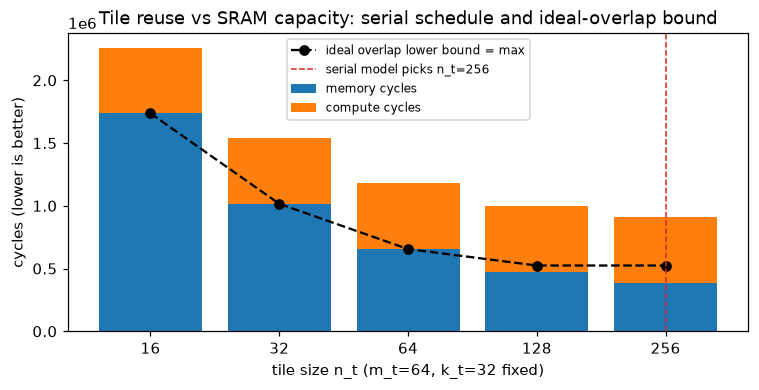

In [8]:
def matmul_cost(M, N, K, m_t, n_t, k_t,
                sram=SRAM_BYTES, mac_per_cycle=MAC_PER_CYCLE, bw=DRAM_BW):
    """固定 loop order=(i,j,k) 的简化 cost model；不合法 tile 返回 None。"""
    working_set = (m_t * k_t + k_t * n_t + m_t * n_t) * 2
    if working_set > sram:
        return None
    tile_m = math.ceil(M / m_t)
    tile_n = math.ceil(N / n_t)
    tile_k = math.ceil(K / k_t)

    # 此 schedule 没跨 j 保留 A、没跨 i 保留 W，因此 A 读 tile_n 次、W 读 tile_m 次。
    dram_bytes = (M * K * tile_n + K * N * tile_m + M * N) * 2
    dma_count = tile_m * tile_n * tile_k * 3
    memory_cycles = dram_bytes / bw + dma_count * DMA_LATENCY
    compute_cycles = M * N * K / mac_per_cycle
    return {
        "working_set_kb": working_set / 1024,
        "dram_mb": dram_bytes / 1e6,
        "memory": memory_cycles,
        "compute": compute_cycles,
        "serial_total": memory_cycles + compute_cycles,
        "ideal_overlap_lower_bound": max(memory_cycles, compute_cycles),
    }


M = N = K = 512
n_candidates = [16, 32, 64, 128, 256, 512]
rows = {n: matmul_cost(M, N, K, 64, n, 32) for n in n_candidates}
for n, row in rows.items():
    if row is None:
        print(f"n_t={n:4d}: 不可行（SRAM 工作集超 64KB）")
    else:
        print(
            f"n_t={n:4d}: DRAM={row['dram_mb']:6.2f} MB  "
            f"memory={row['memory']:9.0f}  compute={row['compute']:9.0f}  "
            f"serial={row['serial_total']:9.0f} cycles"
        )

feasible = [n for n in n_candidates if rows[n] is not None]
best = min(feasible, key=lambda n: rows[n]["serial_total"])
fig, ax = plt.subplots(figsize=(7, 3.8))
x_positions = np.arange(len(feasible))
memory_cycles = [rows[n]["memory"] for n in feasible]
compute_cycles = [rows[n]["compute"] for n in feasible]
ideal_bounds = [rows[n]["ideal_overlap_lower_bound"] for n in feasible]
ax.bar(x_positions, memory_cycles, label="memory cycles")
ax.bar(x_positions, compute_cycles, bottom=memory_cycles, label="compute cycles")
ax.plot(x_positions, ideal_bounds, "ko--", label="ideal overlap lower bound = max")
ax.axvline(feasible.index(best), color="tab:red", ls="--", lw=1,
           label=f"serial model picks n_t={best}")
ax.set_xticks(x_positions, [str(n) for n in feasible])
ax.set_xlabel("tile size n_t (m_t=64, k_t=32 fixed)")
ax.set_ylabel("cycles (lower is better)")
ax.set_title("Tile reuse vs SRAM capacity: serial schedule and ideal-overlap bound")
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

图中小 tile 因复用差而被 DRAM traffic 支配；tile 变大后 traffic 降低，但最终会撞到 SRAM 容量墙。黑色虚线是“DMA 与 MMA 完美重叠”的乐观下界，stacked bar 是本篇 simulator 使用的串行 schedule。

下面把 tiling 写成图变换。真实 MLIR 常见做法是产生 `scf.for`，tensor 语义下配 `tensor.extract_slice/insert_slice`，buffer 语义下配 `memref.subview`。玩具为了肉眼可见，直接把 tile 循环**静态展开**成 op 序列；这不是说真正编译器都要展开，而是用 op 数膨胀展示“隐含迭代空间被显式化”。

还要区分两个 pass：

- tiling：改变循环分块与数据复用；
- `convert-linalg-to-loops`：把 structured op 的隐含循环物化出来，本身不替你搜索 tile size。

上一格 cost model 扫的是**外层 SRAM tile**；下面为了把解释器保持在玩具规模，直接选择 `(16,16,32)` 指令 micro-tile 并静态展开，没有再实现“SRAM tile 内嵌 micro-tile”的第二重循环。真实 backend 通常两层都保留。

In [9]:
def _slice(new_ops, src, offset, size):
    op = Operation("linalg.slice", [src], [Type("f16", size)],
                   attrs={"offset": offset, "size": size})
    new_ops.append(op)
    return op


def pass_tile(block, m_t, n_t, k_t):
    """把每个 linalg.matmul 展开成 (i,j,k) 三重平铺的 matmul_tile 链。
    K 方向是累加链：k=0 的 C0 取自 bias 矩阵切片（或 zeros），之后每个 tile 的
    输出是下一个 tile 的累加输入。epilogue 只挂在 K 链的最后一个 tile 上。
    最后用 concat_tiles 把所有 (i,j) tile 拼回 [M,N]（lowering 时它不产生搬运）。"""
    new_ops = []
    for op in list(block):
        if op.op_type != "linalg.matmul":
            new_ops.append(op)
            continue
        A, W = op.operands[0], op.operands[1]
        M, K = A.type.shape
        N = W.type.shape[1]
        assert M % m_t == 0 and N % n_t == 0 and K % k_t == 0, "toy pass 尚未实现 tail tile"
        C0 = op.operands[2] if len(op.operands) == 3 else None
        epi = op.attrs.get("epilogue")
        tiles = {}
        for i in range(0, M, m_t):
            for j in range(0, N, n_t):
                acc = None
                for k in range(0, K, k_t):
                    a = _slice(new_ops, A, (i, k), (m_t, k_t)).results[0]
                    w = _slice(new_ops, W, (k, j), (k_t, n_t)).results[0]
                    if acc is None:
                        if C0 is not None:
                            acc = _slice(new_ops, C0, (i, j), (m_t, n_t)).results[0]
                        else:
                            z = np.zeros((m_t, n_t), np.float16)
                            acc = Operation("linalg.const", result_types=[Type("f16", z.shape)],
                                            attrs={"value": z}).results[0]
                            new_ops.append(acc.op)
                    last = (k + k_t >= K)
                    attrs = {"epilogue": epi} if (last and epi) else {}
                    mt = Operation("linalg.matmul_tile", [a, w, acc],
                                   [Type("f16", (m_t, n_t))], attrs=attrs)
                    new_ops.append(mt)
                    acc = mt.results[0]
                tiles[(i, j)] = acc
        flat = [tiles[(i, j)] for i in range(0, M, m_t) for j in range(0, N, n_t)]
        cat = Operation("linalg.concat_tiles", flat, [Type("f16", (M, N))],
                        attrs={"tile_shape": (m_t, n_t)})
        new_ops.append(cat)
        op.results[0].replace_all_uses_with(cat.results[0])
    block.ops = new_ops


TILED_BLK, TILED_X, TILED_Y = build_linalg_mlp()
pass_fold_bias(TILED_BLK)
pass_fuse_relu(TILED_BLK)
N_OPS_LINALG = len(TILED_BLK.ops)
pass_tile(TILED_BLK, 16, 16, 32)          # m_t=16, n_t=16, k_t=32（k_t 贴 MMA 指令形状）
N_OPS_TILED = len(TILED_BLK.ops)
print_module(TILED_BLK, "tiling 后：1 个 matmul 变成一串 tile（只显示前 25 个 op）", max_ops=25)
tiled_out = run_linalg(TILED_BLK, {TILED_X: X_DATA})[get_outputs(TILED_BLK)[0]]
assert np.allclose(tiled_out, REF_OUT, rtol=1e-2, atol=1e-2)
print("tiling 后语义不变验证 allclose:", True)

// ---- tiling 后：1 个 matmul 变成一串 tile（只显示前 25 个 op） ----
module {
  %2 = "linalg.const"() {value=const<float16[128,128]>} : () -> f16[128,128]
  %3 = "linalg.const"() {value=const<float16[128]>} : () -> f16[128]
  %4 = "linalg.const"() {value=const<float16[128,128]>} : () -> f16[128,128]
  %5 = "linalg.const"() {value=const<float16[128]>} : () -> f16[128]
  %11 = "linalg.const"() {value=const<float16[64,128]>} : () -> f16[64,128]
  %15 = "linalg.slice"(%1) {offset=(0, 0), size=(16, 32)} : (f16[64,128]) -> f16[16,32]
  %16 = "linalg.slice"(%2) {offset=(0, 0), size=(32, 16)} : (f16[128,128]) -> f16[32,16]
  %17 = "linalg.slice"(%11) {offset=(0, 0), size=(16, 16)} : (f16[64,128]) -> f16[16,16]
  %18 = "linalg.matmul_tile"(%15, %16, %17) : (f16[16,32], f16[32,16], f16[16,16]) -> f16[16,16]
  %19 = "linalg.slice"(%1) {offset=(0, 32), size=(16, 32)} : (f16[64,128]) -> f16[16,32]
  %20 = "linalg.slice"(%2) {offset=(32, 0), size=(32, 16)} : (f16[128,128]) -> f16[32,16]
  %21 = "linalg.matmul_t

## §5 Pass 3（lowering）：linalg → npu dialect，以及“缺 kernel”到底缺什么

MLIR 本身主要提供 IR、dialect、rewrite、conversion 与 pass infrastructure，**不会替你的私有 NPU 自动提供可执行 kernel**。你要补的是一条完整 contract：

```text
op semantics / verifier
  → lowering rule
  → instruction or command-buffer encoding
  → firmware/runtime implementation
  → simulator + device profiler counters
```

本篇 lowering 的 legal target 是 `npu.*`：

| source op | target op | 暴露的硬件信息 |
|---|---|---|
| `linalg.const` | `npu.const` | 常量位于 DRAM |
| `linalg.slice` | `npu.dma_load` | offset、size、bytes，DRAM→SRAM |
| `linalg.matmul_tile` | `npu.mma` | `(m,k,n)` 指令 shape 与 epilogue |
| `linalg.concat_tiles` | `npu.alloc + npu.dma_store` | 结果地址与写回流量 |
| 未融合 `add/relu` | `npu.fallback_cpu` 或新增 `npu.elementwise` | device partition 或自定义 kernel |

缺 elementwise kernel 时有三条工程路径，按改动成本从小到大：

1. **融合**：若硬件 MMA epilogue 已支持 bias/relu，就在高层 pattern 中融合，避免中间 tensor 写回；
2. **fallback / partition**：先保证能跑，但付出 device boundary 与 DRAM traffic；
3. **自定义 kernel**：定义 `npu.elementwise`、shape/dtype/layout verifier、lowering、runtime opcode 与 profiler event。只有热点收益覆盖维护成本时才值得。

真实 MLIR 用 `ConversionTarget` 声明哪些 dialect/op legal，用 conversion patterns 将 illegal op 合法化；full conversion 结束仍有 illegal op 就失败，而不是悄悄带到 backend。[Dialect Conversion](https://mlir.llvm.org/docs/DialectConversion/)

In [10]:
def pass_lower(block, elementwise_mode="fallback"):
    """linalg → npu。elementwise_mode 只能是 fallback 或 npu_kernel。"""
    assert elementwise_mode in {"fallback", "npu_kernel"}
    new_ops = []
    for op in list(block):
        op_type = op.op_type
        if op_type == "linalg.const":
            new = Operation(
                "npu.const",
                [],
                [op.results[0].type],
                attrs={"value": op.attrs["value"], "dram": op.results[0].name},
            )
        elif op_type == "linalg.slice":
            size = op.attrs["size"]
            new = Operation(
                "npu.dma_load",
                [op.operands[0]],
                [Type("f16", size)],
                attrs={
                    "offset": op.attrs["offset"],
                    "size": size,
                    "bytes": int(np.prod(size)) * 2,
                },
            )
        elif op_type == "linalg.matmul_tile":
            m, k = op.operands[0].type.shape
            n = op.operands[1].type.shape[1]
            new = Operation(
                "npu.mma",
                list(op.operands),
                [op.results[0].type],
                attrs={"shape": (m, k, n), "epilogue": op.attrs.get("epilogue", "none")},
            )
        elif op_type == "linalg.concat_tiles":
            M, N = op.results[0].type.shape
            m_t, n_t = op.attrs["tile_shape"]
            alloc = Operation(
                "npu.alloc",
                [],
                [Type("f16", (M, N))],
                attrs={"shape": (M, N), "bytes": M * N * 2},
            )
            new_ops.append(alloc)
            for tile_index, tile in enumerate(op.operands):
                i, j = divmod(tile_index, N // n_t)
                new_ops.append(Operation(
                    "npu.dma_store",
                    [tile, alloc.results[0]],
                    [],
                    attrs={
                        "offset": (i * m_t, j * n_t),
                        "size": (m_t, n_t),
                        "bytes": m_t * n_t * 2,
                    },
                ))
            op.results[0].replace_all_uses_with(alloc.results[0])
            continue
        elif op_type in ("linalg.relu", "linalg.add"):
            target_op = "npu.elementwise" if elementwise_mode == "npu_kernel" else "npu.fallback_cpu"
            new = Operation(
                target_op,
                list(op.operands),
                [op.results[0].type],
                attrs={"orig": op_type},
            )
        else:
            new_ops.append(op)
            continue

        new_ops.append(new)
        if op.results:
            op.results[0].replace_all_uses_with(new.results[0])
    block.ops = new_ops


NPU_BLK, NPU_X, NPU_Y = build_linalg_mlp()
pass_fold_bias(NPU_BLK)
pass_fuse_relu(NPU_BLK)
pass_tile(NPU_BLK, 16, 16, 32)
pass_lower(NPU_BLK, elementwise_mode="fallback")
N_OPS_NPU = len(NPU_BLK.ops)
print_module(NPU_BLK, "npu 层伪汇编：内存搬运和指令 shape 已显式", max_ops=18)

// ---- npu 层伪汇编：内存搬运和指令 shape 已显式 ----
module {
  %849 = "npu.const"() {value=const<float16[128,128]>, dram='%2'} : () -> f16[128,128]
  %850 = "npu.const"() {value=const<float16[128]>, dram='%3'} : () -> f16[128]
  %851 = "npu.const"() {value=const<float16[128,128]>, dram='%4'} : () -> f16[128,128]
  %852 = "npu.const"() {value=const<float16[128]>, dram='%5'} : () -> f16[128]
  %853 = "npu.const"() {value=const<float16[64,128]>, dram='%11'} : () -> f16[64,128]
  %854 = "npu.dma_load"(%1) {offset=(0, 0), size=(16, 32), bytes=1024} : (f16[64,128]) -> f16[16,32]
  %855 = "npu.dma_load"(%849) {offset=(0, 0), size=(32, 16), bytes=1024} : (f16[128,128]) -> f16[32,16]
  %856 = "npu.dma_load"(%853) {offset=(0, 0), size=(16, 16), bytes=512} : (f16[64,128]) -> f16[16,16]
  %857 = "npu.mma"(%854, %855, %856) {shape=(16, 32, 16), epilogue='none'} : (f16[16,32], f16[32,16], f16[16,16]) -> f16[16,16]
  %858 = "npu.dma_load"(%1) {offset=(0, 32), size=(16, 32), bytes=1024} : (f16[64,128]) -> f16[16,

In [11]:
class NpuSim:
    """功能解释器 + 静态性能模型。所有性能数值只属于本篇假想硬件。"""
    def __init__(self):
        self.cycles = 0.0
        self.dram_bytes = 0
        self.inst = Counter()
        self.cycles_by_kind = Counter()
        self.bytes_by_kind = Counter()

    def account(self, kind, cycles, nbytes=0):
        self.cycles += cycles
        self.dram_bytes += nbytes
        self.cycles_by_kind[kind] += cycles
        self.bytes_by_kind[kind] += nbytes

    def dma(self, nbytes):
        self.account("dma", DMA_LATENCY + nbytes / DRAM_BW, nbytes)

    def mma(self, m, k, n):
        self.account("mma", m * k * n / MAC_PER_CYCLE)

    def cpu_fallback(self, input_bytes, output_bytes, elements):
        # 简化且偏悲观：每个 fallback op 都单独发生 device boundary。
        boundary_cycles = 256
        memory_cycles = (input_bytes + output_bytes) / DRAM_BW
        compute_cycles = elements * 2
        self.account(
            "cpu_fallback",
            boundary_cycles + memory_cycles + compute_cycles,
            input_bytes + output_bytes,
        )

    def npu_elementwise(self, input_bytes, output_bytes, elements):
        # 新增的 toy kernel：16-cycle launch，64 elements/cycle；仍需读写 DRAM。
        launch_cycles = 16
        memory_cycles = (input_bytes + output_bytes) / DRAM_BW
        compute_cycles = elements / 64
        self.account(
            "npu_elementwise",
            launch_cycles + memory_cycles + compute_cycles,
            input_bytes + output_bytes,
        )


def run_npu(block, inputs, sim):
    env = dict(inputs)
    for op in block:
        op_type = op.op_type
        if op_type == "func.return":
            continue
        sim.inst[op_type] += 1
        if op_type == "npu.const":
            env[op.results[0]] = op.attrs["value"]
        elif op_type == "npu.dma_load":
            source = env[op.operands[0]]
            (offset_0, offset_1), (size_0, size_1) = op.attrs["offset"], op.attrs["size"]
            env[op.results[0]] = source[
                offset_0:offset_0 + size_0,
                offset_1:offset_1 + size_1,
            ].copy()
            sim.dma(op.attrs["bytes"])
        elif op_type == "npu.mma":
            a, weight, accumulator = (env[value].astype(np.float32) for value in op.operands)
            output = accumulator + a @ weight
            if op.attrs["epilogue"] == "relu":
                output = np.maximum(output, 0)
            env[op.results[0]] = output.astype(np.float16)
            sim.mma(*op.attrs["shape"])
        elif op_type == "npu.alloc":
            env[op.results[0]] = np.empty(op.attrs["shape"], np.float16)
        elif op_type == "npu.dma_store":
            source, destination = env[op.operands[0]], env[op.operands[1]]
            (offset_0, offset_1), (size_0, size_1) = op.attrs["offset"], op.attrs["size"]
            destination[
                offset_0:offset_0 + size_0,
                offset_1:offset_1 + size_1,
            ] = source
            sim.dma(op.attrs["bytes"])
        elif op_type in ("npu.fallback_cpu", "npu.elementwise"):
            first = env[op.operands[0]]
            if op.attrs["orig"] == "linalg.add":
                second = env[op.operands[1]]
                output = (first.astype(np.float32) + second.astype(np.float32)).astype(np.float16)
                input_bytes = first.nbytes + second.nbytes
            else:
                output = np.maximum(first, 0).astype(np.float16)
                input_bytes = first.nbytes
            env[op.results[0]] = output
            if op_type == "npu.fallback_cpu":
                sim.cpu_fallback(input_bytes, output.nbytes, output.size)
            else:
                sim.npu_elementwise(input_bytes, output.nbytes, output.size)
    return env


sim = NpuSim()
npu_out = run_npu(NPU_BLK, {NPU_X: X_DATA}, sim)[get_outputs(NPU_BLK)[0]]
assert np.allclose(npu_out, REF_OUT, rtol=1e-2, atol=1e-2)
print("端到端数值验证 allclose:", np.allclose(npu_out, REF_OUT, rtol=1e-2, atol=1e-2))
print("指令计数               :", dict(sim.inst))
print(f"总 cycles              : {sim.cycles:,.0f}")
print(f"DRAM 流量              : {sim.dram_bytes / 1e6:.2f} MB")
print("cycles breakdown        :", {k: round(v) for k, v in sim.cycles_by_kind.items()})

端到端数值验证 allclose: True
指令计数               : {'npu.const': 6, 'npu.dma_load': 576, 'npu.mma': 256, 'npu.alloc': 2, 'npu.dma_store': 64}
总 cycles              : 65,536
DRAM 流量              : 0.59 MB
cycles breakdown        : {'dma': 57344, 'mma': 8192}


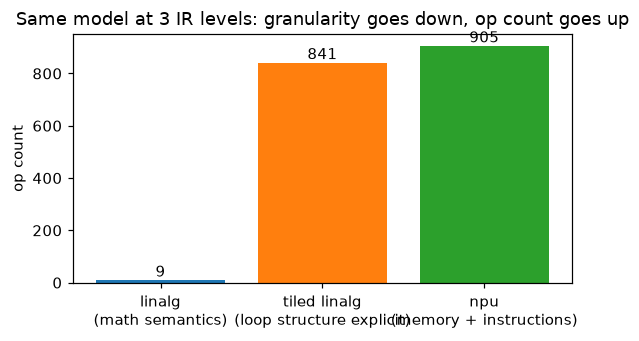

In [12]:
# 颗粒度下探的代价：同一模型在三层 IR 上的 op 数量（信息显式化 = op 数膨胀）
fig, ax = plt.subplots(figsize=(5.5, 3.2))
stages = ["linalg\n(math semantics)", "tiled linalg\n(loop structure explicit)",
          "npu\n(memory + instructions)"]
counts = [N_OPS_LINALG, N_OPS_TILED, N_OPS_NPU]
bars = ax.bar(stages, counts, color=["tab:blue", "tab:orange", "tab:green"])
for b, c in zip(bars, counts):
    ax.text(b.get_x() + b.get_width() / 2, b.get_height(), str(c), ha="center", va="bottom")
ax.set_ylabel("op count")
ax.set_title("Same model at 3 IR levels: granularity goes down, op count goes up")
plt.tight_layout()
plt.show()

## §6 缺 kernel 的三条路：fallback → 自定义 kernel → epilogue fusion

下面保持模型、tile 与硬件规格不变，只切换 elementwise 的实现：

- **V0 fallback**：`add/relu` 回 CPU；本模拟器偏悲观地按每个 op 计算一次 boundary；
- **V1 custom kernel**：新增 `npu.elementwise`，假设 64 elements/cycle，但中间 tensor 仍要经过 DRAM；
- **V2 fused epilogue**：bias/relu 在高层 fusion pass 中并入 MMA，避免额外 materialization。

这三个版本分别回答：先让模型跑通、为热点补 kernel、以及进一步做 graph+kernel 协同优化。性能比较必须在 correctness 全部通过之后才有意义。

V0 CPU fallback             correct=True  cycles=   117536  DRAM= 0.66 MB  breakdown={'dma': 53248, 'mma': 8192, 'cpu_fallback': 56096}
V1 custom NPU elementwise   correct=True  cycles=    68048  DRAM= 0.66 MB  breakdown={'dma': 53248, 'mma': 8192, 'npu_elementwise': 6608}
V2 fused MMA epilogue       correct=True  cycles=    65536  DRAM= 0.59 MB  breakdown={'dma': 57344, 'mma': 8192}


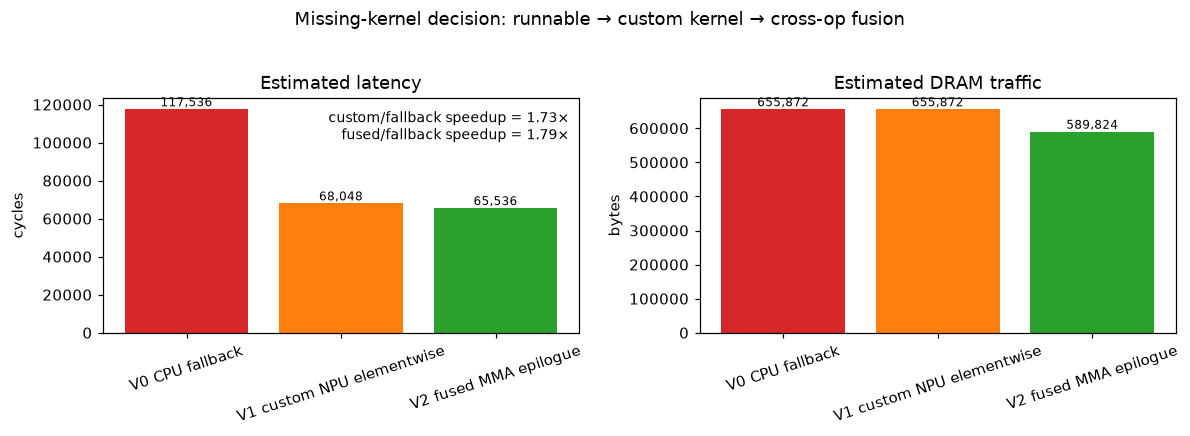

In [13]:
def run_pipeline(*, fuse, elementwise_mode, tile=(16, 16, 32)):
    block, input_value, _ = build_linalg_mlp()
    if fuse:
        pass_fold_bias(block)
        pass_fuse_relu(block)
    pass_tile(block, *tile)
    pass_lower(block, elementwise_mode=elementwise_mode)
    simulator = NpuSim()
    output = run_npu(block, {input_value: X_DATA}, simulator)[get_outputs(block)[0]]
    return output, simulator


variants = {
    "V0 CPU fallback": run_pipeline(fuse=False, elementwise_mode="fallback"),
    "V1 custom NPU elementwise": run_pipeline(fuse=False, elementwise_mode="npu_kernel"),
    "V2 fused MMA epilogue": run_pipeline(fuse=True, elementwise_mode="fallback"),
}
for name, (output, simulator) in variants.items():
    is_correct = np.allclose(output, REF_OUT, rtol=1e-2, atol=1e-2)
    assert is_correct
    print(
        f"{name:27s} correct={is_correct}  "
        f"cycles={simulator.cycles:9.0f}  DRAM={simulator.dram_bytes / 1e6:5.2f} MB  "
        f"breakdown={dict((k, round(v)) for k, v in simulator.cycles_by_kind.items())}"
    )

labels = list(variants)
cycles = [variants[label][1].cycles for label in labels]
dram_bytes = [variants[label][1].dram_bytes for label in labels]
fig, axes = plt.subplots(1, 2, figsize=(11, 3.8))
for axis, values, ylabel, title in [
    (axes[0], cycles, "cycles", "Estimated latency"),
    (axes[1], dram_bytes, "bytes", "Estimated DRAM traffic"),
]:
    bars = axis.bar(labels, values, color=["tab:red", "tab:orange", "tab:green"])
    for bar, value in zip(bars, values):
        axis.text(
            bar.get_x() + bar.get_width() / 2,
            value,
            f"{value:,.0f}",
            ha="center",
            va="bottom",
            fontsize=8,
        )
    axis.set_ylabel(ylabel)
    axis.set_title(title)
    axis.tick_params(axis="x", rotation=18)
axes[0].text(
    0.98,
    0.95,
    f"custom/fallback speedup = {cycles[0] / cycles[1]:.2f}×\n"
    f"fused/fallback speedup = {cycles[0] / cycles[2]:.2f}×",
    transform=axes[0].transAxes,
    ha="right",
    va="top",
    fontsize=9,
)
plt.suptitle("Missing-kernel decision: runnable → custom kernel → cross-op fusion", y=1.03)
plt.tight_layout()
plt.show()

## §7 映射到真实 MLIR 与私有 NPU 后端

### 7.1 一条真实 dialect conversion 的骨架

下面不是完整可编译工程，但名字和职责对应真实 MLIR C++ API：

```cpp
ConversionTarget target(context);
target.addLegalDialect<npu::NpuDialect>();
target.addLegalDialect<func::FuncDialect>();
target.addIllegalOp<linalg::MatmulOp>();

RewritePatternSet patterns(&context);
patterns.add<MatmulToNpuMma, AddToNpuElementwise>(&context, hardwareSpec);

if (failed(applyFullConversion(module, target, std::move(patterns))))
  return signalPassFailure();
```

`MatmulToNpuMma::matchAndRewrite` 内部就是本篇的 match / build / replace；`ConversionTarget` 则保证不支持的 source op 不会悄悄漏到 codegen。[Pattern Rewriting](https://mlir.llvm.org/docs/PatternRewriter/)

### 7.2 新 NPU backend 的实际开发顺序

1. **写硬件 contract**：支持的 dtype、layout、MMA shape、alignment、SRAM/memory space、DMA 与同步语义；
2. **定义 dialect / types / attributes / verifier**：如 `!npu.sram_tensor`、`npu.mma`、`npu.dma`、`npu.event`；
3. **先做 capability 与 partition**：每个 op 标为 supported / unsupported，保证 fallback correctness；
4. **写 lowering**：structured op → tile/pack → bufferize → memory planning → NPU command IR；
5. **补 kernel / microcode / runtime ABI**：dialect op 只是 compiler contract，不等于硬件已经会执行；
6. **scheduler**：DMA/MMA dependency、double buffering、barrier、multi-core mapping；
7. **codegen**：序列化 command buffer / binary，runtime 分配 buffer 并提交设备；
8. **闭环验证**：eager golden output → simulator → 板上输出；static cost → timeline → hardware counters。

### 7.3 性能问题怎样定位

最小证据链不是只看端到端 latency，而是逐层对齐：

```text
IR dump：fusion/tiling/partition 是否如预期
  ↓
command trace：DMA、MMA、barrier 的时间顺序
  ↓
hardware counters：MAC utilization、DMA busy、stall、SRAM bank conflict、bytes
  ↓
cost model vs measured：差值来自 launch、同步、带宽折损还是 shape tail
  ↓
改 pass / tile / schedule，再过 correctness gate
```

常见判断：MAC utilization 低且 DMA busy 高 → 复用/tiling；DMA 与 MMA 中间大片空洞 → scheduler/double buffering；device 切换多 → partition/fusion；只有某个 shape 慢 → kernel coverage 或 tail handling。

### 7.4 `mlir-opt` 最小检视命令

`--convert-linalg-to-loops` 只展示 structured op 如何变成显式 loops，不代表已经做 tiling：

```bash
/opt/homebrew/opt/llvm/bin/mlir-opt matmul.mlir \
  --convert-linalg-to-loops \
  --mlir-print-ir-after-all

/opt/homebrew/opt/llvm/bin/mlir-opt --help | rg -i 'linalg|transform'
```

真正的 tile size 选择通常通过 transform dialect、定制 pass 或 autotuner 驱动；具体 CLI 随 LLVM 版本变化，应先看本机 `--help`，不要背固定参数。官方资料：[Linalg dialect](https://mlir.llvm.org/docs/Dialects/Linalg/)、[Transform dialect](https://mlir.llvm.org/docs/Dialects/Transform/)、[Pass Management](https://mlir.llvm.org/docs/PassManagement/)。

In [14]:
# 只做只读探测，不自动安装 LLVM。Homebrew 的 LLVM 通常不进入系统 PATH。
from pathlib import Path

mlir_candidates = [
    shutil.which("mlir-opt"),
    "/opt/homebrew/opt/llvm/bin/mlir-opt",
    "/usr/local/opt/llvm/bin/mlir-opt",
]
mlir_opt = next(
    (candidate for candidate in mlir_candidates if candidate and Path(candidate).is_file()),
    None,
)
if mlir_opt:
    print("found mlir-opt at:", mlir_opt)
else:
    print(
        "mlir-opt 未安装；本 Notebook 的 Python toy compiler 不依赖它。"
        "如需执行真实 .mlir 文本，可选安装 Homebrew LLVM，再先运行 mlir-opt --help。"
    )

mlir-opt 未安装；本 Notebook 的 Python toy compiler 不依赖它。如需执行真实 .mlir 文本，可选安装 Homebrew LLVM，再先运行 mlir-opt --help。


## Takeaways

1. **MIL 不是 MLIR 的缩写，也不是跨厂商通用 IR。** MIL 是 Core ML converter 的 typed SSA IR；ML Program 是它序列化后的 Core ML model type；MLIR 是用于构造多层 dialect/IR 的 compiler framework。
2. **同一个“Program”有两种物理表示。** `milinternal` 返回 Python `Program/Function/Operation/Var` 对象图；`mlprogram` 的 model spec 是 protobuf `Model → MIL_pb2.Program → Function → Block → Operation`，保存进 `.mlpackage`。
3. **IR 颗粒度由优化窗口决定。** fusion 需要高层 op 语义；tiling 需要迭代空间与访问映射；DMA scheduling 需要 memory space、地址与 event。先优化再丢语义。
4. **rewrite 的骨架是 match → build → replace/erase。** MLIR 再用 legality、type conversion、dominance 和 side-effect interfaces 把它工程化。
5. **缺 kernel 的三条路都要量化。** fallback 先保 correctness，自定义 kernel 降低 device/compute 代价，epilogue fusion 进一步省掉中间 DRAM traffic；最终以真机 counters 而非 toy cost model 定案。

### 建议练习

1. 给 `pass_tile` 增加“shape 必须整除 tile”的 verifier，再实现尾块（tail tile）；这是实际 kernel coverage 的高频问题。
2. 把 simulator 从串行改为 `max(DMA, MMA)` 的理想 double-buffering，再加入 barrier/launch cost，观察理论收益上限。
3. 给 `npu.elementwise` 加 layout/alignment 限制，让部分 shape fallback；打印 partition boundary 数量。
4. 在公司 SoC 上记录同一组指标：NPU cycles、DDR bytes、MAC utilization、DMA stall；用实测数据替换本篇的假设常量。

### 官方参考

- [Core ML Model Intermediate Language](https://apple.github.io/coremltools/docs-guides/source/model-intermediate-language.html)
- [Comparing ML Programs and Neural Networks](https://apple.github.io/coremltools/docs-guides/source/comparing-ml-programs-and-neural-networks.html)
- [ONNX IR Specification](https://onnx.ai/onnx/repo-docs/IR.html)
- [MLIR Language Reference](https://mlir.llvm.org/docs/LangRef/)
- [MLIR Dialect Conversion](https://mlir.llvm.org/docs/DialectConversion/)
- [MLIR Pattern Rewriting](https://mlir.llvm.org/docs/PatternRewriter/)